# Pose Clustering & Clinical Analysis Pipeline (v2)

**Pipeline:** pose coordinates -> normalize skeleton (hip-centred, torso-scaled) -> joint angles + relative coords   (SkeletonFeatureExtractor) -> PCA   (StandardScaler → PCA @ 95% var) -> clustering   (K-Means, optimal k via silhouette + elbow)

Changes:
- **Skeleton normalization**: torso-length scaling + hip-centering eliminates position/scale bias
- **Feature engineering**: joint angles (elbow, knee, shoulder, hip) + relative joint positions replace raw pixel coords
- **PCA** is applied before clustering (dimensionality reduction, denoising)
- Velocity features are retained as supplementary features alongside geometry

In [1]:
"""
Pose Clustering and Clinical Analysis Pipeline v2
"""
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.ERROR, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

## Configuration

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

class Config:
    """Central configuration for analysis parameters"""

    # Movement detection
    MOVEMENT_THRESHOLD = 10   # pixels/frame for "moving"

    # Proximity zones
    PROXIMITY_CLOSE  = 200    # pixels
    PROXIMITY_MEDIUM = 400    # pixels

    # Response analysis
    RESPONSE_WINDOW = 5       # seconds to check for child response

    # Data preprocessing
    CONFIDENCE_THRESHOLD = 0.5
    SMOOTH_WINDOW = 11
    SMOOTH_POLY  = 3

    # Clustering
    K_RANGE = range(2, 8)

    # PCA – number of components to keep before clustering
    # None → keep components that explain 95 % of variance
    PCA_N_COMPONENTS = None
    PCA_VARIANCE_THRESHOLD = 0.95

    # Session phase analysis
    PHASE_WINDOW = 30         # seconds per window
    N_PHASES = 4

    # Role labels
    THERAPIST_LABEL = "Therapist"
    CHILD_LABEL     = "Child"

    # -----------------------------------------------------------------
    # Keypoint names as they appear in the CSV columns
    # (used for skeleton normalization and angle computation)
    # -----------------------------------------------------------------
    KEYPOINTS = [
        "nose",
        "l_shoulder", "r_shoulder",
        "l_elbow",    "r_elbow",
        "l_wrist",    "r_wrist",
        "l_hip",      "r_hip",
        "l_knee",     "r_knee",
        "l_ankle",    "r_ankle",
    ]

    # Joint-angle triplets (vertex is the middle joint)
    # Format: (joint_A, vertex_joint, joint_B, angle_name)
    ANGLE_TRIPLETS = [
        ("l_shoulder", "l_elbow",    "l_wrist",    "l_elbow_angle"),
        ("r_shoulder", "r_elbow",    "r_wrist",    "r_elbow_angle"),
        ("l_elbow",    "l_shoulder", "l_hip",      "l_shoulder_angle"),
        ("r_elbow",    "r_shoulder", "r_hip",      "r_shoulder_angle"),
        ("l_shoulder", "l_hip",      "l_knee",     "l_hip_angle"),
        ("r_shoulder", "r_hip",      "r_knee",     "r_hip_angle"),
        ("l_hip",      "l_knee",     "l_ankle",    "l_knee_angle"),
        ("r_hip",      "r_knee",     "r_ankle",    "r_knee_angle"),
        ("l_hip",      "r_hip",      "r_knee",     "trunk_lean"),   # trunk lean proxy
    ]

## Step 1 – Data Loading & Preprocessing

In [3]:
# =============================================================================
# PART 1: DATA PREPROCESSING
# =============================================================================

class DataPreprocessor:
    """Load, filter, interpolate and smooth raw pose data."""

    def __init__(self, config=None):
        self.config = config or Config()
        self.df = None

    def load_data(self, filepath):
        """Load pose data from CSV."""
        self.df = pd.read_csv(filepath)
        self.df['person_label'] = self.df['person_label'].replace({
            'Patient1':   'Child',
            'Therapist1': 'Therapist'
        })
        self.df = self.df[
            self.df['person_label'].isin(['Child', 'Therapist'])
        ].reset_index(drop=True)

        print(f"Loaded {len(self.df)} rows, {len(self.df.columns)} columns")
        print(f"Participants found: {list(self.df['person_label'].unique())}")
        return self.df

    def preprocess(self):
        """Filter by confidence, interpolate gaps, smooth coordinates."""
        # --- confidence filter ---
        self.df = self.df[
            self.df['avg_pose_conf'] > self.config.CONFIDENCE_THRESHOLD
        ].copy()

        # --- drop rows with NaN in numeric coordinate columns ---
        coord_cols_raw = [c for c in self.df.columns
                          if c.endswith('_x') or c.endswith('_y')]
        self.df = self.df.dropna(subset=coord_cols_raw, how='all').reset_index(drop=True)

        # --- Savitzky-Golay smoothing ---
        coord_cols = [c for c in self.df.columns
                      if c.endswith('_x') or c.endswith('_y')]
        for col in coord_cols:
            self.df[f"{col}_smooth"] = (
                self.df
                .groupby('person_label')[col]
                .transform(lambda x:
                    savgol_filter(
                        x,
                        window_length=self.config.SMOOTH_WINDOW,
                        polyorder=self.config.SMOOTH_POLY
                    ) if len(x) >= self.config.SMOOTH_WINDOW else x
                )
            )
        return self.df

    def compute_body_metrics(self):
        """Centre-of-mass, velocities (head, hands, COM)."""
        x_cols = [c for c in self.df.columns if c.endswith('_x_smooth')]
        y_cols = [c for c in self.df.columns if c.endswith('_y_smooth')]
        if not x_cols:
            x_cols = [c for c in self.df.columns
                      if c.endswith('_x') and '_smooth' not in c and c != 'com_x']
            y_cols = [c for c in self.df.columns
                      if c.endswith('_y') and '_smooth' not in c and c != 'com_y']

        self.df['com_x'] = self.df[x_cols].mean(axis=1)
        self.df['com_y'] = self.df[y_cols].mean(axis=1)

        for axis in ('x', 'y'):
            self.df[f'com_{axis}_vel'] = (
                self.df.groupby('person_label')[f'com_{axis}'].diff() /
                self.df.groupby('person_label')['time_s'].diff()
            )
        self.df['com_speed'] = np.sqrt(
            self.df['com_x_vel']**2 + self.df['com_y_vel']**2
        )

        # head
        for sfx in ('_smooth', ''):
            if f'nose_x{sfx}' in self.df.columns:
                self.df['head_x'] = self.df[f'nose_x{sfx}']
                self.df['head_y'] = self.df[f'nose_y{sfx}']
                break
        for axis in ('x', 'y'):
            self.df[f'head_{axis}_vel'] = (
                self.df.groupby('person_label')[f'head_{axis}'].diff() /
                self.df.groupby('person_label')['time_s'].diff()
            )
        self.df['head_speed'] = np.sqrt(
            self.df['head_x_vel']**2 + self.df['head_y_vel']**2
        )

        # hands (avg wrists)
        def _col(name):
            s = f'{name}_smooth'
            return s if s in self.df.columns else name

        self.df['hands_x'] = (self.df[_col('r_wrist_x')] + self.df[_col('l_wrist_x')]) / 2
        self.df['hands_y'] = (self.df[_col('r_wrist_y')] + self.df[_col('l_wrist_y')]) / 2
        for axis in ('x', 'y'):
            self.df[f'hands_{axis}_vel'] = (
                self.df.groupby('person_label')[f'hands_{axis}'].diff() /
                self.df.groupby('person_label')['time_s'].diff()
            )
        self.df['hands_speed'] = np.sqrt(
            self.df['hands_x_vel']**2 + self.df['hands_y_vel']**2
        )
        return self.df

## Step 2 – Skeleton Normalization + Feature Engineering

Raw pixel coordinates encode **where** a person is in the frame, not **how** they are posed.  
Normalization removes camera-position and body-size confounds so that clustering captures *posture*, not *location*.

### What we do per frame
1. **Translate** – subtract the mid-hip point so the pelvis is at the origin  
2. **Scale** – divide by torso length (mid-shoulder <-> mid-hip) so bodies of different sizes are comparable  
3. **Joint angles** – compute 9 anatomically-meaningful angles (elbow, shoulder, hip, knee, trunk lean)  
4. **Relative coordinates** – keep the normalized (x, y) of every keypoint as additional features

In [4]:
# =============================================================================
# PART 2: SKELETON NORMALIZATION + FEATURE ENGINEERING
# =============================================================================

class SkeletonFeatureExtractor:
    """
    Transforms raw keypoint pixel coordinates into a pose-invariant
    feature vector:
        1. translate to hip-centred frame
        2. scale by torso length
        3. compute joint angles
        4. stack normalised (x, y) + angles as final feature matrix
    """

    def __init__(self, config=None):
        self.config = config or Config()

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _get_xy(self, row, joint):
        """Return (x, y) for a joint, preferring smoothed columns."""
        for sfx in ('_x_smooth', '_x'):
            col = f'{joint}{sfx}'
            if col in row.index and not pd.isna(row[col]):
                y_col = col.replace('_x', '_y')
                return np.array([row[col], row[y_col]], dtype=float)
        return np.array([np.nan, np.nan])

    @staticmethod
    def _angle_at_vertex(a, v, b):
        """
        Angle (degrees) at vertex v formed by rays v→a and v→b.
        Returns NaN if any point is NaN.
        """
        if np.any(np.isnan(a)) or np.any(np.isnan(v)) or np.any(np.isnan(b)):
            return np.nan
        va = a - v
        vb = b - v
        cos_angle = np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-9)
        return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

    # ------------------------------------------------------------------
    # Core normalization
    # ------------------------------------------------------------------

    def normalize_skeleton(self, row):
        """
        For a single DataFrame row:
          1. compute mid-hip and torso length
          2. translate & scale every keypoint
        Returns dict {joint: np.array([nx, ny])}
        """
        cfg = self.config

        l_hip = self._get_xy(row, 'l_hip')
        r_hip = self._get_xy(row, 'r_hip')
        l_sho = self._get_xy(row, 'l_shoulder')
        r_sho = self._get_xy(row, 'r_shoulder')

        mid_hip = (l_hip + r_hip) / 2.0
        mid_sho = (l_sho + r_sho) / 2.0
        torso_len = np.linalg.norm(mid_sho - mid_hip)
        if torso_len < 1e-6 or np.isnan(torso_len):
            torso_len = 1.0          # fallback: no scaling

        norm_joints = {}
        for joint in cfg.KEYPOINTS:
            pt = self._get_xy(row, joint)
            norm_joints[joint] = (pt - mid_hip) / torso_len

        return norm_joints, torso_len

    # ------------------------------------------------------------------
    # Feature extraction for a single person
    # ------------------------------------------------------------------

    def extract_features(self, df, person_label):
        """
        Build feature matrix for one person:
          • normalised (x, y) for each keypoint   →  2 × n_joints columns
          • 9 joint angles                         →  9 columns
          • COM speed, head speed, hands speed     →  3 columns

        Returns
        -------
        feature_df : pd.DataFrame  (one row per frame, no time column)
        times      : np.ndarray    (time_s values)
        """
        cfg = self.config
        person_df = df[df['person_label'] == person_label].copy().reset_index(drop=True)

        rows_norm   = []   # normalised coordinates
        rows_angles = []   # joint angles

        for _, row in person_df.iterrows():
            norm_joints, _ = self.normalize_skeleton(row)

            # --- relative coordinates ---
            coord_dict = {}
            for joint, pt in norm_joints.items():
                coord_dict[f'{joint}_nx'] = pt[0]
                coord_dict[f'{joint}_ny'] = pt[1]
            rows_norm.append(coord_dict)

            # --- joint angles ---
            angle_dict = {}
            for (jA, vertex, jB, name) in cfg.ANGLE_TRIPLETS:
                a = norm_joints.get(jA,     np.array([np.nan, np.nan]))
                v = norm_joints.get(vertex, np.array([np.nan, np.nan]))
                b = norm_joints.get(jB,     np.array([np.nan, np.nan]))
                angle_dict[name] = self._angle_at_vertex(a, v, b)
            rows_angles.append(angle_dict)

        coord_df  = pd.DataFrame(rows_norm,   index=person_df.index)
        angle_df  = pd.DataFrame(rows_angles, index=person_df.index)

        # --- velocity features (already computed in DataPreprocessor) ---
        vel_cols = ['com_speed', 'head_speed', 'hands_speed']
        vel_df = person_df[[c for c in vel_cols if c in person_df.columns]].copy()

        feature_df = pd.concat([coord_df, angle_df, vel_df], axis=1)

        # fill residual NaNs
        feature_df = feature_df.ffill().bfill().fillna(0)

        times = person_df['time_s'].values
        print(f"  [{person_label}] feature matrix: "
              f"{feature_df.shape[0]} frames × {feature_df.shape[1]} features ")
        print(f"     → {len(coord_df.columns)//2} keypoints (normalised coords) + "
              f"{len(angle_df.columns)} angles + "
              f"{len(vel_df.columns)} velocity features")

        return feature_df, times

## Step 3 – PCA

PCA reduces the feature space before clustering:
- removes correlated/redundant dimensions (many keypoints move together)
- denoises minor jitter
- makes K-Means distance metric more meaningful in lower-dimensional space

By default we keep enough components to explain **95 %** of variance.

In [5]:
# =============================================================================
# PART 3: PCA
# =============================================================================

class PoseReducer:
    """
    Standardise → PCA on skeleton feature matrix.
    Keeps components that explain `variance_threshold` of total variance
    (or a fixed number if pca_n_components is set).
    """

    def __init__(self, config=None):
        self.config = config or Config()
        self.scaler = StandardScaler()
        self.pca = None
        self.n_components_chosen = None

    def fit_transform(self, feature_df):
        """
        Standardise then project features onto principal components.

        Returns
        -------
        X_pca   : np.ndarray  shape (n_frames, n_components)
        """
        X = self.scaler.fit_transform(feature_df.values)

        if self.config.PCA_N_COMPONENTS is not None:
            n_comp = self.config.PCA_N_COMPONENTS
        else:
            # fit full PCA first to inspect cumulative variance
            full_pca = PCA()
            full_pca.fit(X)
            cumvar = np.cumsum(full_pca.explained_variance_ratio_)
            n_comp = int(np.searchsorted(cumvar, self.config.PCA_VARIANCE_THRESHOLD) + 1)

        self.pca = PCA(n_components=n_comp, random_state=42)
        X_pca = self.pca.fit_transform(X)
        self.n_components_chosen = n_comp

        explained = self.pca.explained_variance_ratio_.sum()
        print(f"  PCA: {n_comp} components retained "
              f"({explained:.1%} variance explained)")

        return X_pca

    def get_explained_variance(self):
        if self.pca is None:
            raise RuntimeError("Call fit_transform first.")
        return self.pca.explained_variance_ratio_

## Step 4 – Clustering (K-Means on PCA space)

In [6]:
# =============================================================================
# PART 4: CLUSTERING
# =============================================================================

class PoseClusterer:
    """
    K-Means clustering directly on PCA-reduced features.
    Optimal k is chosen by combining silhouette score and elbow analysis.
    """

    def __init__(self, config=None):
        self.config = config or Config()
        self.kmeans = None
        self.optimal_k = None

    def find_optimal_k(self, X_pca):
        """Sweep k values and choose optimal k."""
        k_values  = list(self.config.K_RANGE)
        sil_scores    = []
        inertia_scores = []

        for k in k_values:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(X_pca)
            inertia_scores.append(km.inertia_)
            sil_scores.append(
                silhouette_score(X_pca, labels) if k > 1 else -1
            )

        # silhouette winner
        valid = [(i, s) for i, s in enumerate(sil_scores) if s > -1]
        best_sil_idx, best_sil_score = max(valid, key=lambda x: x[1])
        optimal_k_sil = k_values[best_sil_idx]

        # elbow winner (2nd derivative of normalised inertia)
        if len(k_values) >= 3:
            inertia_norm = np.array(inertia_scores) / max(inertia_scores)
            elbow_idx = int(np.argmax(np.diff(inertia_norm, n=2))) + 2
            optimal_k_elbow = k_values[elbow_idx]
        else:
            optimal_k_elbow = optimal_k_sil

        # decide
        threshold = 0.05
        if optimal_k_sil != optimal_k_elbow:
            elbow_sil = sil_scores[k_values.index(optimal_k_elbow)]
            self.optimal_k = (
                optimal_k_elbow
                if best_sil_score - elbow_sil <= threshold
                else optimal_k_sil
            )
        else:
            self.optimal_k = optimal_k_sil

        print(f"  Optimal k = {self.optimal_k}  "
              f"(silhouette: {best_sil_score:.3f})")
        return self.optimal_k, sil_scores, inertia_scores, k_values

    def fit_predict(self, X_pca, n_clusters=None):
        """Fit K-Means and return cluster labels."""
        if n_clusters is None:
            n_clusters = self.optimal_k if self.optimal_k else 3

        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = self.kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)
        print(f"  Clustering: {n_clusters} clusters  (silhouette: {sil:.3f})")
        return labels

## Step 5 – Clinical Interaction Analysis (unchanged)

In [7]:
# =============================================================================
# PART 5: CLINICAL INTERACTION ANALYSIS
# =============================================================================

class ClinicalAnalyzer:
    """Analyzes therapist-child interactions."""

    def __init__(self, df, config=None):
        self.df = df
        self.config = config or Config()
        self.movement_profiles   = {}
        self.proximity_df        = None
        self.approach_events_df  = None
        self.lagged_corr_df      = None
        self.phases_df           = None

    def analyze_movement_profiles(self):
        for label in [self.config.THERAPIST_LABEL, self.config.CHILD_LABEL]:
            person_data = self.df[self.df['person_label'] == label].copy()
            if person_data.empty:
                continue
            person_data['is_moving'] = (
                person_data['com_speed'] > self.config.MOVEMENT_THRESHOLD
            )
            self.movement_profiles[label] = {
                'total_frames':       len(person_data),
                'activity_ratio':     person_data['is_moving'].mean(),
                'mean_speed':         person_data['com_speed'].mean(),
                'max_speed':          person_data['com_speed'].max(),
                'mean_head_speed':    person_data['head_speed'].mean(),
                'mean_hand_speed':    person_data['hands_speed'].mean(),
                'spatial_coverage_x': person_data['com_x'].max() - person_data['com_x'].min(),
                'spatial_coverage_y': person_data['com_y'].max() - person_data['com_y'].min(),
            }
        return self.movement_profiles

    def analyze_proximity(self):
        t_data = self.df[self.df['person_label'] == self.config.THERAPIST_LABEL][
            ['time_s', 'com_x', 'com_y', 'com_speed']].copy()
        c_data = self.df[self.df['person_label'] == self.config.CHILD_LABEL][
            ['time_s', 'com_x', 'com_y', 'com_speed']].copy()

        merged = pd.merge(t_data, c_data, on='time_s',
                         suffixes=('_therapist', '_child'))
        if merged.empty:
            return pd.DataFrame()

        merged['distance'] = np.sqrt(
            (merged['com_x_therapist'] - merged['com_x_child'])**2 +
            (merged['com_y_therapist'] - merged['com_y_child'])**2
        )
        merged['proximity_zone'] = 'far'
        merged.loc[merged['distance'] < self.config.PROXIMITY_MEDIUM, 'proximity_zone'] = 'medium'
        merged.loc[merged['distance'] < self.config.PROXIMITY_CLOSE,  'proximity_zone'] = 'close'
        merged['distance_vel'] = (
            merged['distance'].diff() / merged['time_s'].diff()
        )
        self.proximity_df = merged
        return self.proximity_df

    def detect_approach_response(self):
        if self.proximity_df is None or self.proximity_df.empty:
            return pd.DataFrame()

        self.proximity_df['approaching'] = (
            (self.proximity_df['distance_vel'] < -5) &
            (self.proximity_df['com_speed_therapist'] > self.config.MOVEMENT_THRESHOLD)
        )
        approach_starts = self.proximity_df[
            self.proximity_df['approaching'] &
            ~self.proximity_df['approaching'].shift(1).fillna(False)
        ]

        events = []
        for _, approach in approach_starts.iterrows():
            t0 = approach['time_s']
            child_window = self.df[
                (self.df['person_label'] == self.config.CHILD_LABEL) &
                (self.df['time_s'] >= t0) &
                (self.df['time_s'] <= t0 + self.config.RESPONSE_WINDOW)
            ]
            if len(child_window) == 0:
                continue
            moved = child_window['com_speed'] > self.config.MOVEMENT_THRESHOLD
            moving_frames = child_window[moved]
            events.append({
                'approach_time':     t0,
                'initial_distance':  approach['distance'],
                'child_responded':   moved.any(),
                'child_head_response':  (child_window['head_speed']  > self.config.MOVEMENT_THRESHOLD).any(),
                'child_hand_response':  (child_window['hands_speed'] > self.config.MOVEMENT_THRESHOLD).any(),
                'response_latency':  (
                    moving_frames['time_s'].iloc[0] - t0
                    if len(moving_frames) > 0 else None
                ),
                'therapist_speed':   approach['com_speed_therapist'],
            })

        self.approach_events_df = pd.DataFrame(events)
        return self.approach_events_df

    def compute_lagged_correlation(self, max_lag=10):
        t_data = self.df[self.df['person_label'] == self.config.THERAPIST_LABEL].sort_values('time_s')
        c_data = self.df[self.df['person_label'] == self.config.CHILD_LABEL].sort_values('time_s')
        merged = pd.merge(
            t_data[['time_s', 'com_speed']],
            c_data[['time_s', 'com_speed']],
            on='time_s', suffixes=('_therapist', '_child')
        ).dropna()
        if len(merged) < 50:
            return pd.DataFrame()

        dt = merged['time_s'].diff().mean()
        correlations = []
        for lag in range(-max_lag, max_lag + 1):
            if lag < 0:
                ts = merged['com_speed_therapist'].iloc[-lag:].values
                cs = merged['com_speed_child'].iloc[:lag].values
            elif lag > 0:
                ts = merged['com_speed_therapist'].iloc[:-lag].values
                cs = merged['com_speed_child'].iloc[lag:].values
            else:
                ts = merged['com_speed_therapist'].values
                cs = merged['com_speed_child'].values
            if len(ts) > 10 and len(ts) == len(cs) and ts.std() > 0 and cs.std() > 0:
                corr, _ = pearsonr(ts, cs)
                correlations.append({'lag': lag, 'lag_seconds': lag * dt, 'correlation': corr})

        self.lagged_corr_df = pd.DataFrame(correlations)
        return self.lagged_corr_df

    def detect_session_phases(self):
        t_data = self.df[self.df['person_label'] == self.config.THERAPIST_LABEL].copy()
        c_data = self.df[self.df['person_label'] == self.config.CHILD_LABEL].copy()
        if t_data.empty or c_data.empty:
            return pd.DataFrame()

        time_bins = np.arange(
            self.df['time_s'].min(),
            self.df['time_s'].max(),
            self.config.PHASE_WINDOW
        )
        phases = []
        for i in range(len(time_bins) - 1):
            ts, te = time_bins[i], time_bins[i + 1]
            tw = t_data[(t_data['time_s'] >= ts) & (t_data['time_s'] < te)]
            cw = c_data[(c_data['time_s'] >= ts) & (c_data['time_s'] < te)]
            if len(tw) == 0 or len(cw) == 0:
                continue
            phases.append({
                'time_start': ts, 'time_end': te,
                'time_mid': (ts + te) / 2,
                'therapist_activity':   (tw['com_speed'] > self.config.MOVEMENT_THRESHOLD).mean(),
                'child_activity':       (cw['com_speed'] > self.config.MOVEMENT_THRESHOLD).mean(),
                'therapist_mean_speed': tw['com_speed'].mean(),
                'child_mean_speed':     cw['com_speed'].mean(),
            })

        self.phases_df = pd.DataFrame(phases)
        if len(self.phases_df) < self.config.N_PHASES:
            return self.phases_df

        feats = self.phases_df[[
            'therapist_activity', 'child_activity',
            'therapist_mean_speed', 'child_mean_speed'
        ]].values
        km = KMeans(n_clusters=self.config.N_PHASES, random_state=42, n_init=10)
        self.phases_df['phase'] = km.fit_predict(feats)
        return self.phases_df

## Step 6 – Visualisation

In [8]:
# =============================================================================
# PART 6: VISUALIZATION
# =============================================================================

class Visualizer:
    """Comprehensive visualisations for both clinical and clustering results."""

    # poster-style sizes
    TS, LS, TK, LS2 = 36, 32, 28, 26

    COLORS = {
        'Therapist':   '#440154',
        'Child':       '#31688e',
        'Response':    '#35b779',
        'No Response': '#fde725',
    }

    @classmethod
    def plot_clinical_overview(cls, clinical_analyzer, save_path=None):
        df   = clinical_analyzer.df
        cfg  = clinical_analyzer.config
        prox = clinical_analyzer.proximity_df
        evts = clinical_analyzer.approach_events_df
        phs  = clinical_analyzer.phases_df
        out  = Path(save_path).parent if save_path else None

        # 1. Speed
        fig, ax = plt.subplots(figsize=(16, 10))
        for label in [cfg.THERAPIST_LABEL, cfg.CHILD_LABEL]:
            d = df[df['person_label'] == label].copy()
            d['spd_smooth'] = d['com_speed'].rolling(50, center=True, min_periods=1).mean()
            ax.plot(d['time_s'].values, d['spd_smooth'].values,
                    label=label, linewidth=4, color=cls.COLORS[label])
        ax.set_title('Movement Speed (Smoothed)', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Time (s)', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Speed (px/frame)', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.legend(fontsize=cls.LS2)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / 'movement_speed.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 2. Proximity
        fig, ax = plt.subplots(figsize=(16, 10))
        if prox is not None and not prox.empty:
            x = prox['time_s'].values
            y = prox['distance'].values
            mask = ~np.isnan(y)
            x, y = x[mask], y[mask]
            x_new = np.linspace(x.min(), x.max(), 500)
            y_sm  = gaussian_filter1d(
                interp1d(x, y, kind='linear', fill_value='extrapolate')(x_new), sigma=5
            )
            ax.plot(x_new, y_sm, linewidth=4, color='#31688e')
            ax.axhline(cfg.PROXIMITY_CLOSE,  color='red',    ls='--', lw=3, alpha=0.6, label='Close')
            ax.axhline(cfg.PROXIMITY_MEDIUM, color='orange', ls='--', lw=3, alpha=0.6, label='Medium')
            ax.legend(fontsize=cls.LS2)
        ax.set_title('Inter-person Distance', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Time (s)', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Distance (pixels)', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / 'proximity_distance.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 3. Approach events
        fig, ax = plt.subplots(figsize=(16, 10))
        if evts is not None and not evts.empty:
            for responded, color, label in [
                (True,  cls.COLORS['Response'],    'Response'),
                (False, cls.COLORS['No Response'], 'No response')
            ]:
                sub = evts[evts['child_responded'] == responded]
                ax.scatter(sub['approach_time'], sub['initial_distance'],
                          color=color, s=300, alpha=0.8,
                          edgecolor='black', linewidth=3, label=label)
            ax.legend(fontsize=cls.LS2)
        ax.set_title('Approach Events', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Time (s)', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Distance (pixels)', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / 'approach_events.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 4. Session phases
        fig, ax = plt.subplots(figsize=(16, 10))
        if phs is not None and not phs.empty and 'phase' in phs.columns:
            colors = plt.cm.viridis(np.linspace(0.2, 0.9, phs['phase'].nunique()))
            for idx, pid in enumerate(sorted(phs['phase'].unique())):
                sub = phs[phs['phase'] == pid]
                ax.scatter(sub['therapist_activity'] * 100, sub['child_activity'] * 100,
                          s=400, alpha=0.7, color=colors[idx],
                          edgecolor='black', linewidth=3, label=f'Phase {pid+1}')
            ax.legend(fontsize=cls.LS2)
        ax.set_title('Session Phases', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Therapist Activity (%)', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Child Activity (%)', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / 'session_phases.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

    @classmethod
    def plot_pca_variance(cls, reducer, person_label, save_path=None):
        """Scree plot showing PCA explained variance."""
        ratios = reducer.get_explained_variance()
        cumsum = np.cumsum(ratios)
        out = Path(save_path).parent if save_path else None

        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        axes[0].bar(range(1, len(ratios)+1), ratios * 100,
                   color='#440154', edgecolor='black', alpha=0.8)
        axes[0].set_title(f'PCA Scree – {person_label}', fontsize=cls.TS, weight='bold')
        axes[0].set_xlabel('Component', fontsize=cls.LS, weight='bold')
        axes[0].set_ylabel('Explained Variance (%)', fontsize=cls.LS, weight='bold')
        axes[0].tick_params(labelsize=cls.TK)
        axes[0].grid(True, alpha=0.3, axis='y')

        axes[1].plot(range(1, len(cumsum)+1), cumsum * 100,
                    'o-', linewidth=4, markersize=10, color='#31688e',
                    markeredgecolor='black', markeredgewidth=2)
        axes[1].axhline(95, color='red', ls='--', lw=3, alpha=0.7, label='95%')
        axes[1].set_title(f'Cumulative Variance – {person_label}', fontsize=cls.TS, weight='bold')
        axes[1].set_xlabel('Components', fontsize=cls.LS, weight='bold')
        axes[1].set_ylabel('Cumulative Variance (%)', fontsize=cls.LS, weight='bold')
        axes[1].tick_params(labelsize=cls.TK)
        axes[1].legend(fontsize=cls.LS2)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        if out: fig.savefig(out / f'pca_variance_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

    @classmethod
    def plot_clustering_results(cls, X_pca, labels, times, person_label,
                                 optimal_k, sil_scores, inertia_scores,
                                 k_values, save_path=None):
        out = Path(save_path).parent if save_path else None

        # 1. Silhouette
        fig, ax = plt.subplots(figsize=(16, 10))
        ax.plot(k_values, sil_scores, 'o-', linewidth=4, markersize=15,
               color='#440154', markeredgecolor='black', markeredgewidth=2)
        ax.axvline(optimal_k, color='red', ls='--', lw=4, alpha=0.7,
                  label=f'Optimal k={optimal_k}')
        ax.set_title('Silhouette Method', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('k', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Silhouette Score', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.legend(fontsize=cls.LS2)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / f'silhouette_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 2. Elbow
        fig, ax = plt.subplots(figsize=(16, 10))
        ax.plot(k_values, inertia_scores, 'o-', linewidth=4, markersize=15,
               color='#31688e', markeredgecolor='black', markeredgewidth=2)
        ax.set_title('Elbow Method', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('k', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Inertia (WCSS)', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.grid(True, alpha=0.3)
        if out: fig.savefig(out / f'elbow_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 3. PCA scatter (first 2 components of the PCA-reduced space)
        fig, ax = plt.subplots(figsize=(16, 10))
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                       cmap='viridis', alpha=0.7, s=150,
                       edgecolor='black', linewidth=0.5)
        ax.set_title(f'PCA Space – {person_label}', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('PC 1', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('PC 2', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        cb = plt.colorbar(sc, ax=ax)
        cb.set_label('Cluster', fontsize=cls.LS, weight='bold')
        cb.ax.tick_params(labelsize=cls.TK)
        if out: fig.savefig(out / f'pca_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 4. Cluster sizes
        fig, ax = plt.subplots(figsize=(16, 10))
        unique, counts = np.unique(labels, return_counts=True)
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(unique)))
        ax.bar(unique, counts, color=colors, edgecolor='black', alpha=0.8, linewidth=3)
        ax.set_title('Cluster Size Distribution', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Cluster', fontsize=cls.LS, weight='bold')
        ax.set_ylabel('Frames', fontsize=cls.LS, weight='bold')
        ax.tick_params(labelsize=cls.TK)
        ax.grid(True, alpha=0.3, axis='y')
        if out: fig.savefig(out / f'cluster_dist_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

        # 5. Cluster timeline
        fig, ax = plt.subplots(figsize=(20, 6))
        sc2 = ax.scatter(times, np.zeros_like(times), c=labels,
                        cmap='tab10', s=20, alpha=0.6)
        ax.set_title(f'Cluster Timeline – {person_label}', fontsize=cls.TS, weight='bold')
        ax.set_xlabel('Time (s)', fontsize=cls.LS, weight='bold')
        ax.set_yticks([])
        ax.tick_params(labelsize=cls.TK)
        plt.colorbar(sc2, ax=ax, label='Cluster', orientation='vertical')
        if out: fig.savefig(out / f'timeline_{person_label}.png', dpi=300, bbox_inches='tight')
        plt.show(); plt.close(fig)

In [9]:
# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_pose_clustering(data_path, output_dir=None, config=None):
    """
    Parameters
    data_path  : str | Path  – CSV file or directory containing processed_data.csv
    output_dir : str | Path  – where to save figures and results CSV
    config     : Config      – optional custom config

    Returns
    dict with keys: data, clinical_analyzer, cluster_results, config
    """

    print("\n" + "="*70)
    print("POSE CLUSTERING PIPELINE  v2")
    print("pose coords > normalize > angles/coords > PCA > clustering")
    print("="*70)

    config = config or Config()

    # resolve CSV path
    data_path = Path(data_path)
    csv_path  = data_path / "processed_data.csv" if data_path.is_dir() else data_path
    if not csv_path.exists():
        raise FileNotFoundError(f"Data file not found: {csv_path}")

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True, parents=True)

    # ----------------------------------------------------------------
    # STEP 1 – load, filter, interpolate, smooth
    # ----------------------------------------------------------------
    print("\n[1/5] Loading and preprocessing data...")
    preprocessor = DataPreprocessor(config)
    df = preprocessor.load_data(csv_path)
    df = preprocessor.preprocess()
    df = preprocessor.compute_body_metrics()

    # ----------------------------------------------------------------
    # STEP 2 – clinical interaction analysis
    # ----------------------------------------------------------------
    print("\n[2/5] Analyzing clinical interactions...")
    clinical = ClinicalAnalyzer(df, config)
    clinical.analyze_movement_profiles()
    clinical.analyze_proximity()
    clinical.detect_approach_response()
    clinical.compute_lagged_correlation()
    clinical.detect_session_phases()

    if output_dir:
        Visualizer.plot_clinical_overview(
            clinical,
            save_path=str(output_dir / 'clinical_analysis.png')
        )

    # ----------------------------------------------------------------
    # STEP 3 – skeleton normalisation + feature engineering   
    # ----------------------------------------------------------------
    print("\n[3/5] Normalising skeleton and engineering features...")
    feat_extractor = SkeletonFeatureExtractor(config)

    # ----------------------------------------------------------------
    # STEP 4+5 – PCA then clustering (per person)   
    # ----------------------------------------------------------------
    print("\n[4/5] PCA + Clustering per person...")
    cluster_results = {}

    for person_label in df['person_label'].unique():
        print(f"\n  ── {person_label} ──")

        try:
            # 3a. extract features
            feature_df, times = feat_extractor.extract_features(df, person_label)

            if len(feature_df) < 20:
                print(f"  Skipping {person_label}: too few frames ({len(feature_df)})")
                continue

            # 4a. PCA
            reducer = PoseReducer(config)
            X_pca   = reducer.fit_transform(feature_df)

            if output_dir:
                Visualizer.plot_pca_variance(
                    reducer, person_label,
                    save_path=str(output_dir / f'pca_variance_{person_label}.png')
                )

            # 5a. clustering
            clusterer = PoseClusterer(config)
            optimal_k, sil_scores, inertia_scores, k_values = \
                clusterer.find_optimal_k(X_pca)
            labels = clusterer.fit_predict(X_pca, n_clusters=optimal_k)

            cluster_results[person_label] = {
                'feature_df':      feature_df,
                'X_pca':           X_pca,
                'labels':          labels,
                'times':           times,
                'optimal_k':       optimal_k,
                'silhouette_scores': sil_scores,
                'inertia_scores':  inertia_scores,
                'k_values':        k_values,
                'reducer':         reducer,
            }

            # visualise
            sp = str(output_dir / f'clustering_{person_label}.png') if output_dir else None
            Visualizer.plot_clustering_results(
                X_pca, labels, times, person_label,
                optimal_k, sil_scores, inertia_scores, k_values,
                save_path=sp
            )

        except Exception as exc:
            print(f"  Error processing {person_label}: {exc}")
            import traceback; traceback.print_exc()
            continue

    # ----------------------------------------------------------------
    # Merge cluster labels back into main DataFrame
    # ----------------------------------------------------------------
    print("\n[5/5] Generating final results...")
    results_dfs = []
    for person_label, res in cluster_results.items():
        results_dfs.append(pd.DataFrame({
            'time_s':       res['times'],
            'person_label': person_label,
            'cluster':      res['labels'],
            'optimal_k':    res['optimal_k'],
        }))

    final_results = df.copy()
    if results_dfs:
        combined = pd.concat(results_dfs, ignore_index=True)
        final_results = df.merge(combined, on=['time_s', 'person_label'], how='left')

    if output_dir:
        out_csv = output_dir / 'pose_clusters_with_clinical.csv'
        final_results.to_csv(out_csv, index=False)
        print(f"  Saved: {out_csv}")

    # ----------------------------------------------------------------
    # Summary
    # ----------------------------------------------------------------
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE – KEY FINDINGS")
    print("="*70)
    print(f"\nDataset: {len(df):,} frames")

    print("\nMovement Profiles:")
    for lbl, m in clinical.movement_profiles.items():
        print(f"  • {lbl}: {m['activity_ratio']*100:.1f}% active  "
              f"(mean speed {m['mean_speed']:.1f} px/frame)")

    if clinical.proximity_df is not None and not clinical.proximity_df.empty:
        md  = clinical.proximity_df['distance'].mean()
        cp  = (clinical.proximity_df['proximity_zone'] == 'close').mean() * 100
        print(f"\nProximity: {md:.0f} px avg distance  ({cp:.1f}% close)")

    if clinical.approach_events_df is not None and not clinical.approach_events_df.empty:
        rr  = clinical.approach_events_df['child_responded'].mean() * 100
        n   = len(clinical.approach_events_df)
        nr  = clinical.approach_events_df['child_responded'].sum()
        print(f"\nResponsiveness: {rr:.1f}% ({nr}/{n} approaches)")
        lats = clinical.approach_events_df[
            clinical.approach_events_df['child_responded']
        ]['response_latency'].dropna()
        if len(lats):
            print(f"  Mean response latency: {lats.mean():.2f}s")

    if clinical.lagged_corr_df is not None and not clinical.lagged_corr_df.empty:
        mx = clinical.lagged_corr_df.loc[
            clinical.lagged_corr_df['correlation'].abs().idxmax()
        ]
        print(f"\nMovement Coupling: r = {mx['correlation']:.3f}  "
              f"at {mx['lag_seconds']:.1f}s lag")

    print("\nPose Clusters (angle + coord features → PCA → K-Means):")
    for lbl, res in cluster_results.items():
        n_comp = res['reducer'].n_components_chosen
        sil    = max(res['silhouette_scores'])
        print(f"  • {lbl}: {res['optimal_k']} posture clusters  "
              f"| PCA: {n_comp} components  "
              f"| silhouette: {sil:.3f}")

    print("\n" + "="*70)

    return {
        'data':              final_results,
        'clinical_analyzer': clinical,
        'cluster_results':   cluster_results,
        'config':            config,
    }

## Run


POSE CLUSTERING PIPELINE  v2
pose coords → normalize → angles/coords → PCA → clustering

[1/5] Loading and preprocessing data...
Loaded 48481 rows, 57 columns
Participants found: ['Therapist', 'Child']

[2/5] Analyzing clinical interactions...


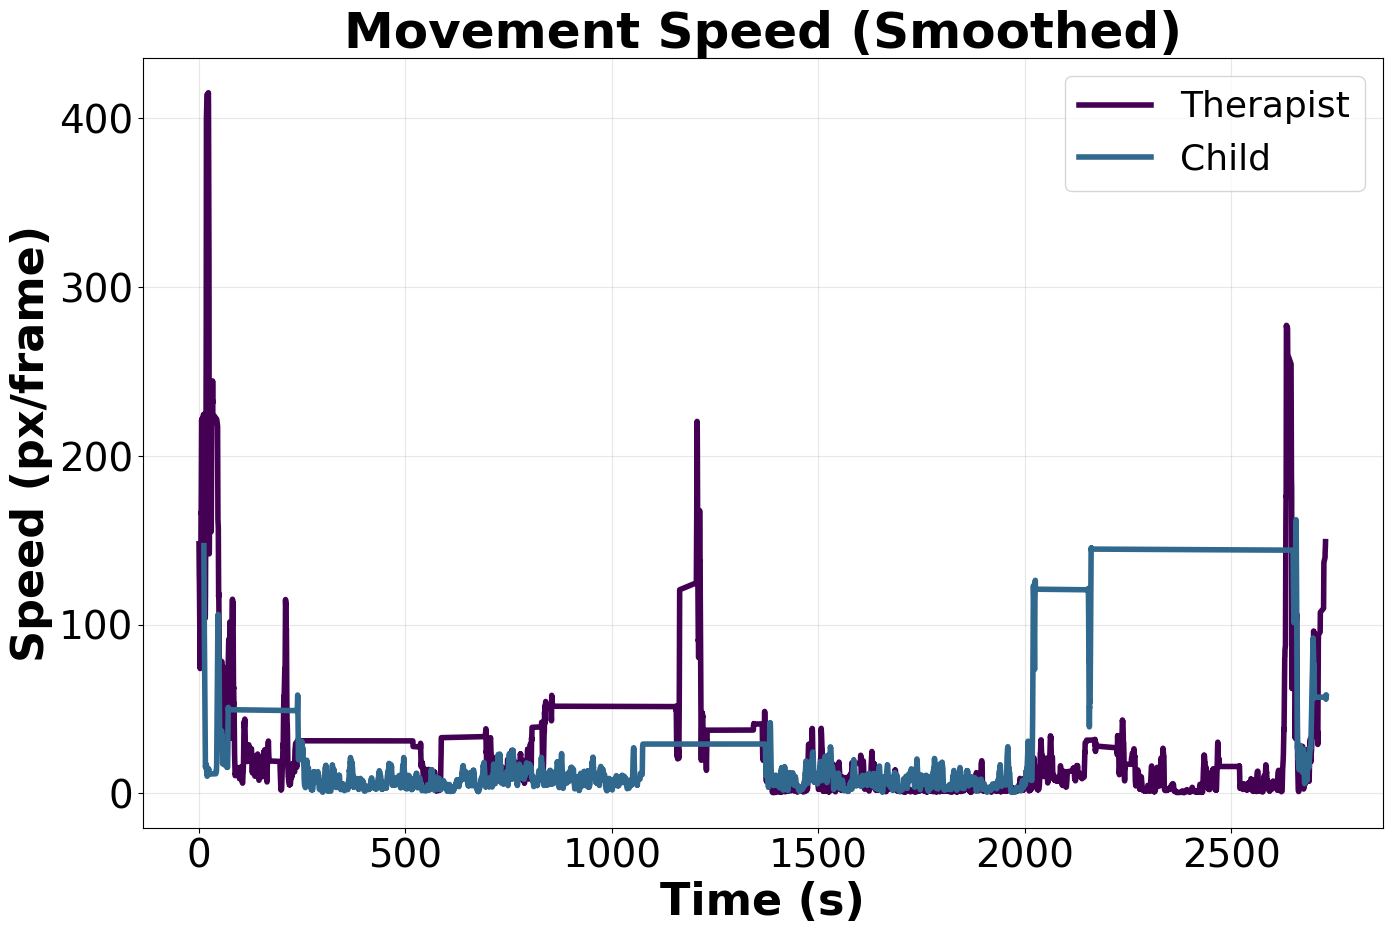

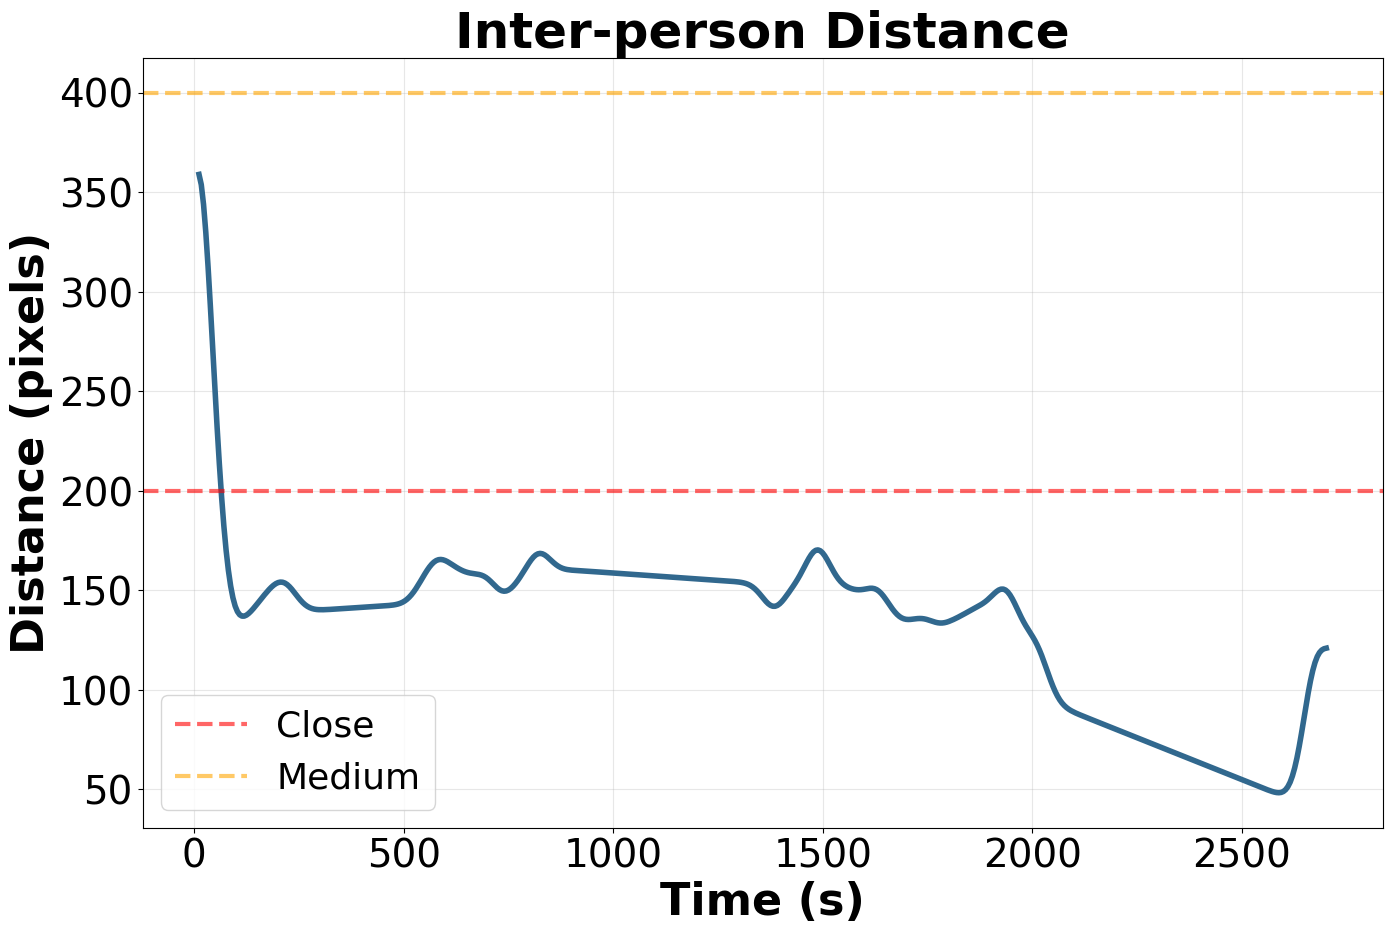

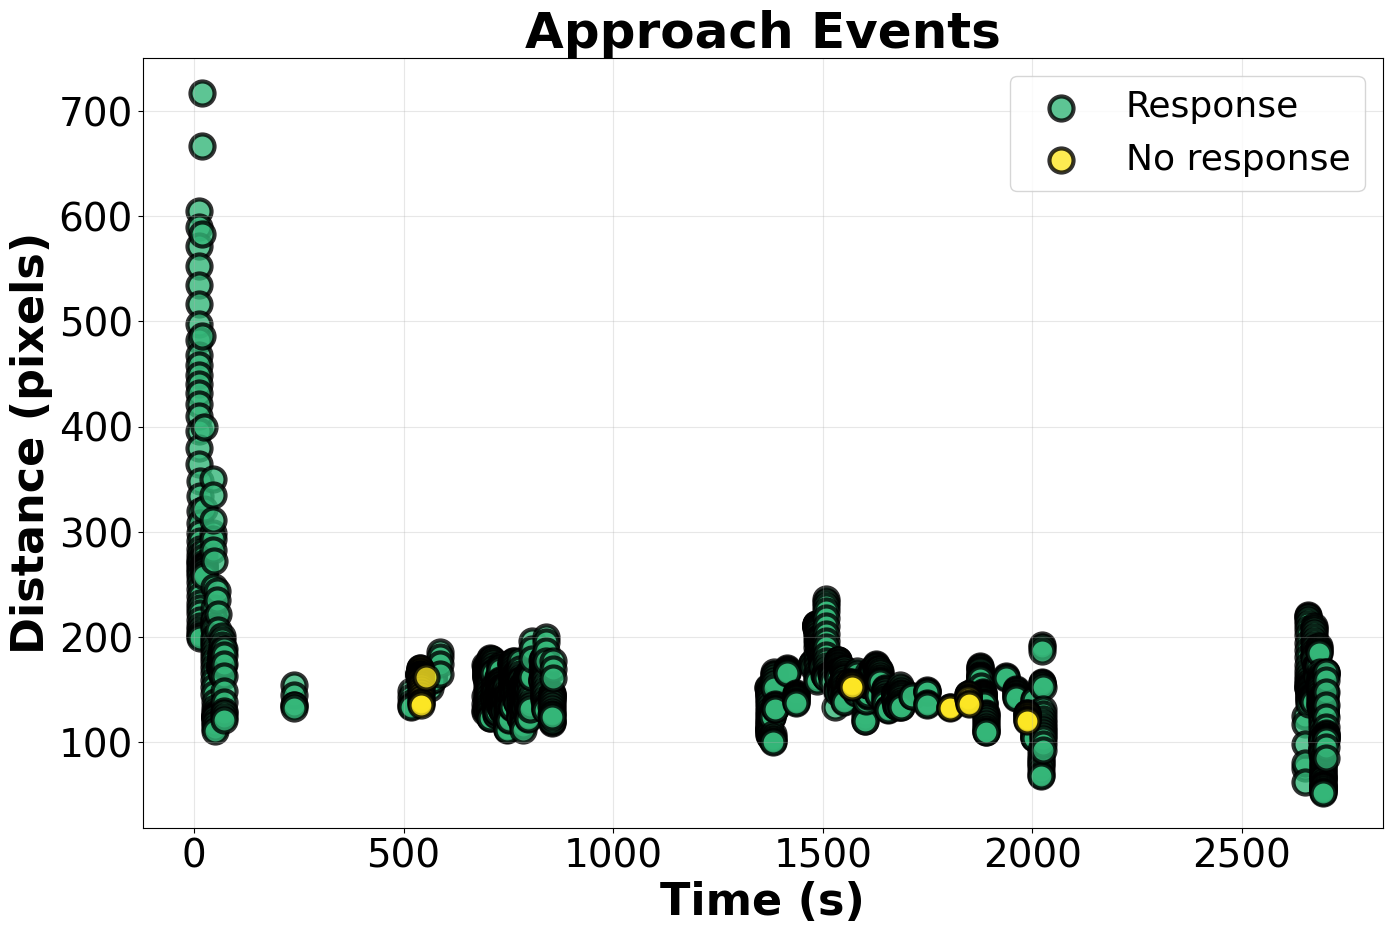

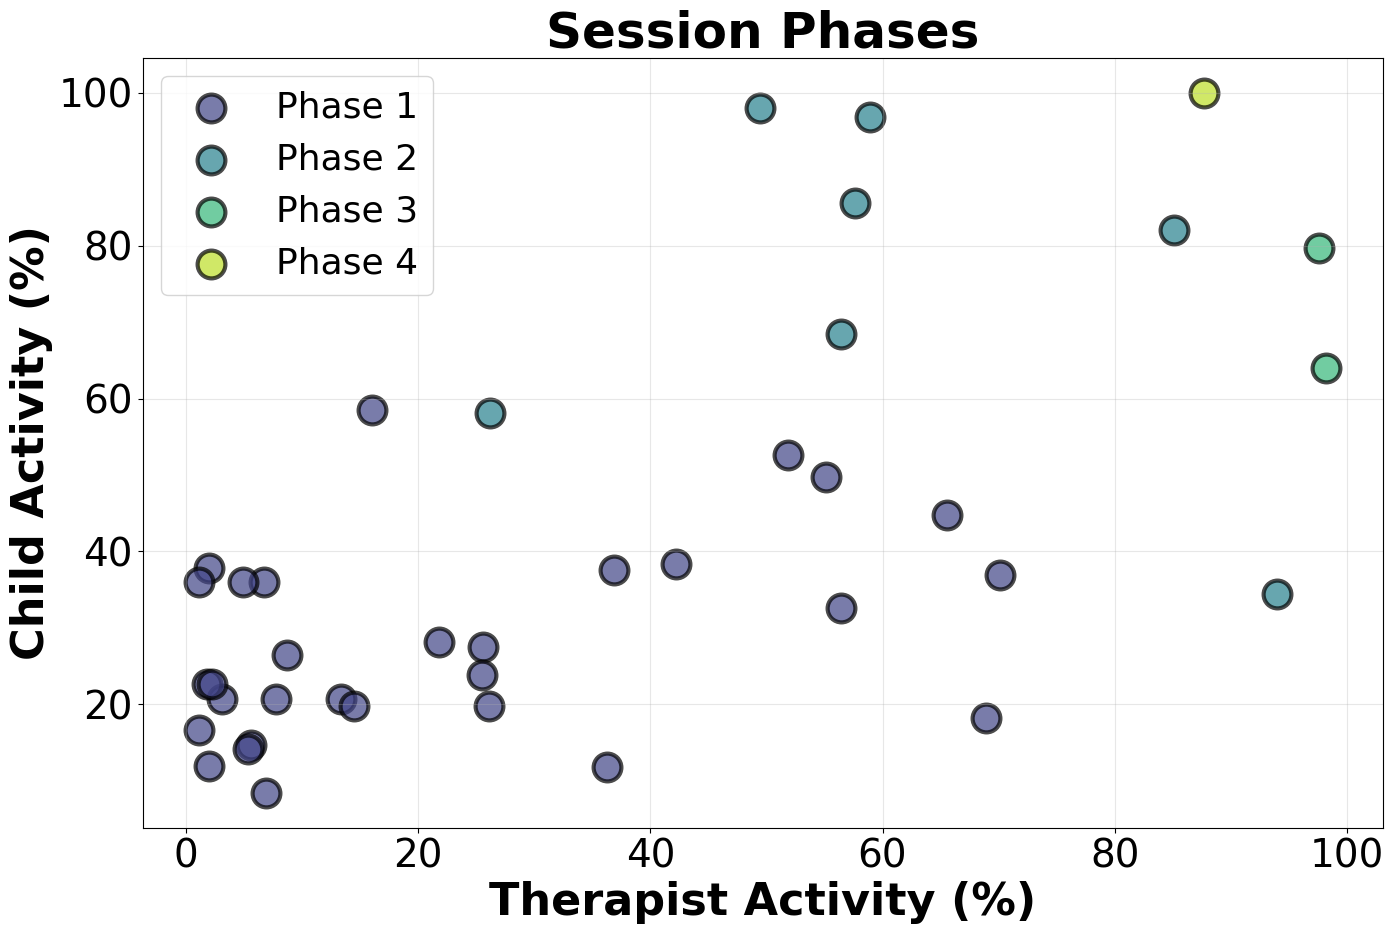


[3/5] Normalising skeleton and engineering features...

[4/5] PCA + Clustering per person...

  ── Therapist ──
  [Therapist] feature matrix: 22987 frames × 38 features 
     → 13 keypoints (normalised coords) + 9 angles + 3 velocity features
  PCA: 11 components retained (95.5% variance explained)


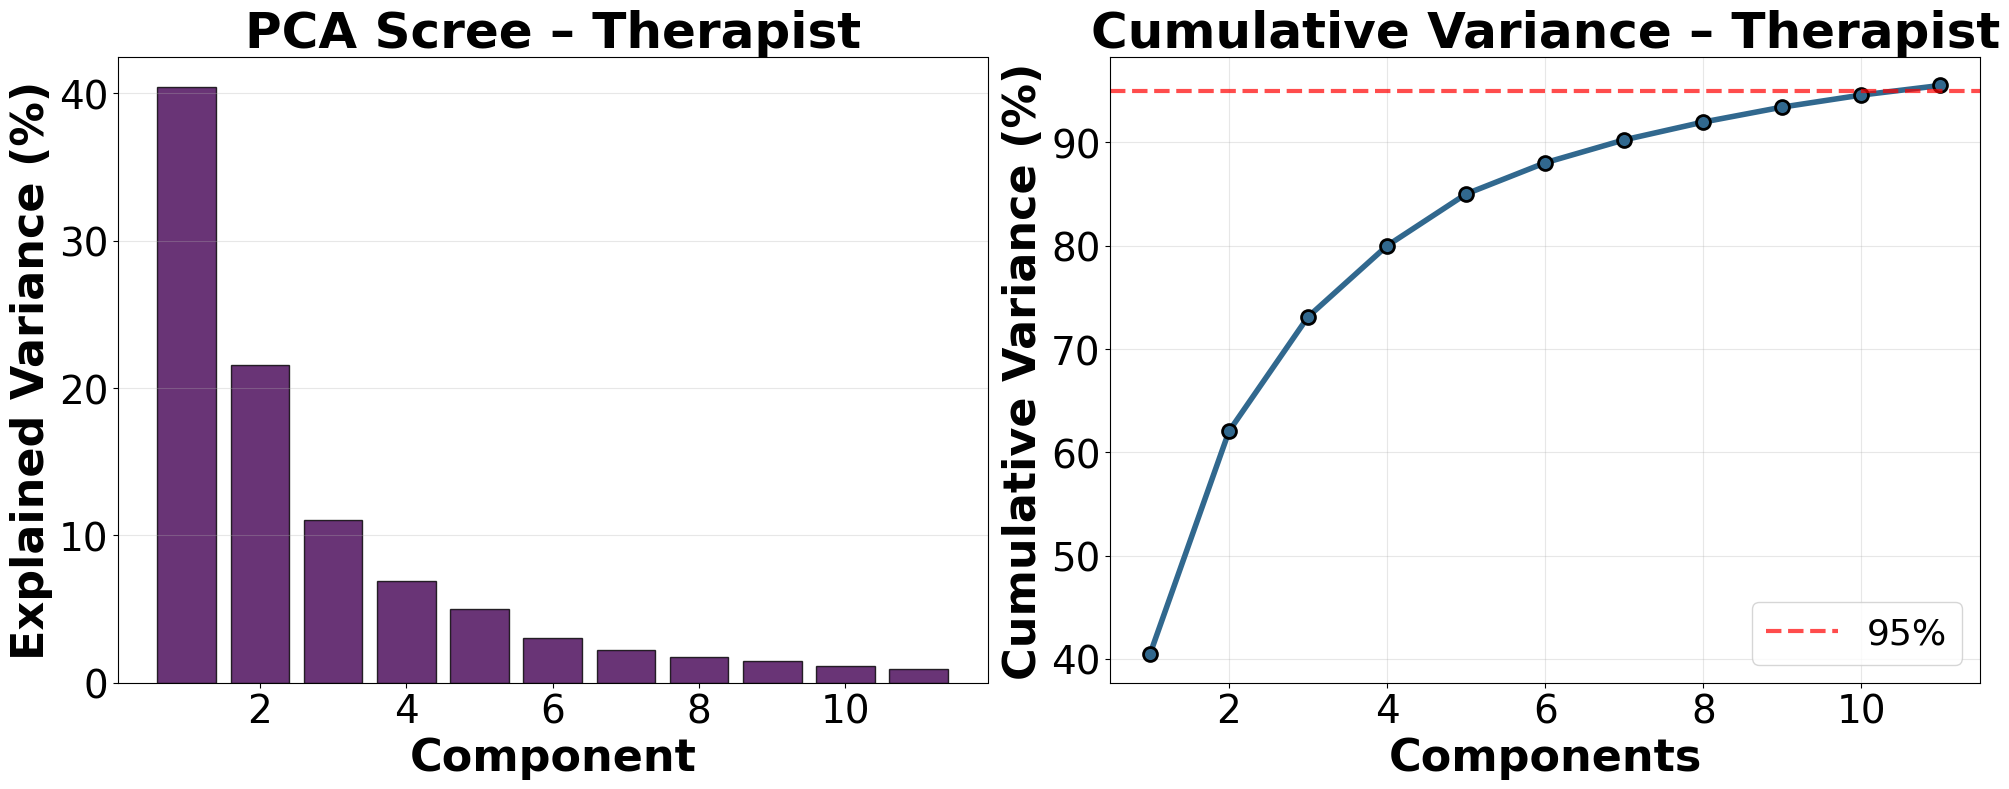

  Optimal k = 2  (silhouette: 0.652)
  Clustering: 2 clusters  (silhouette: 0.652)


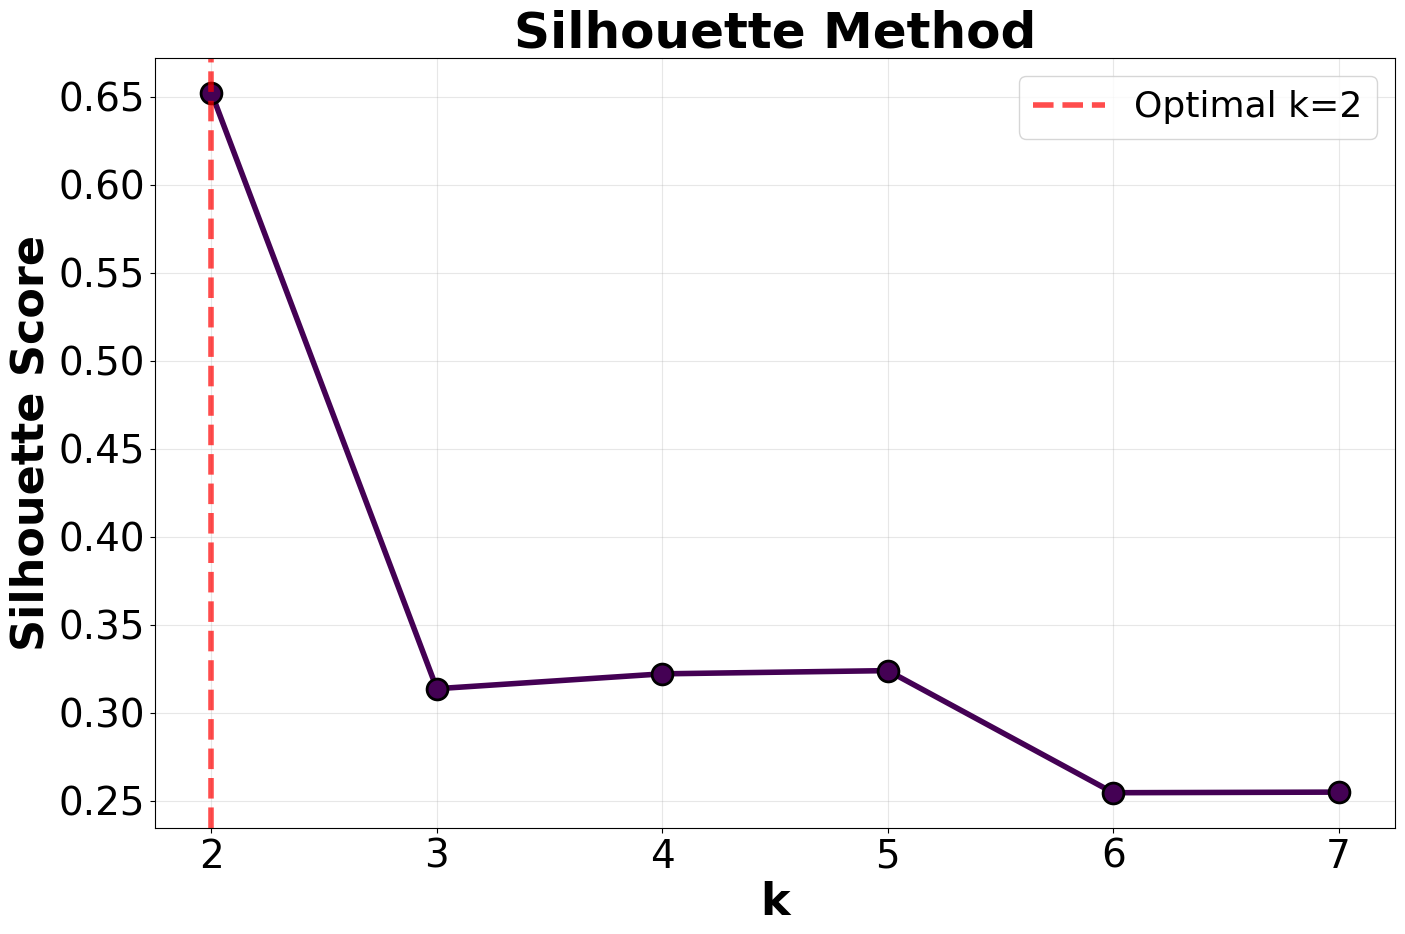

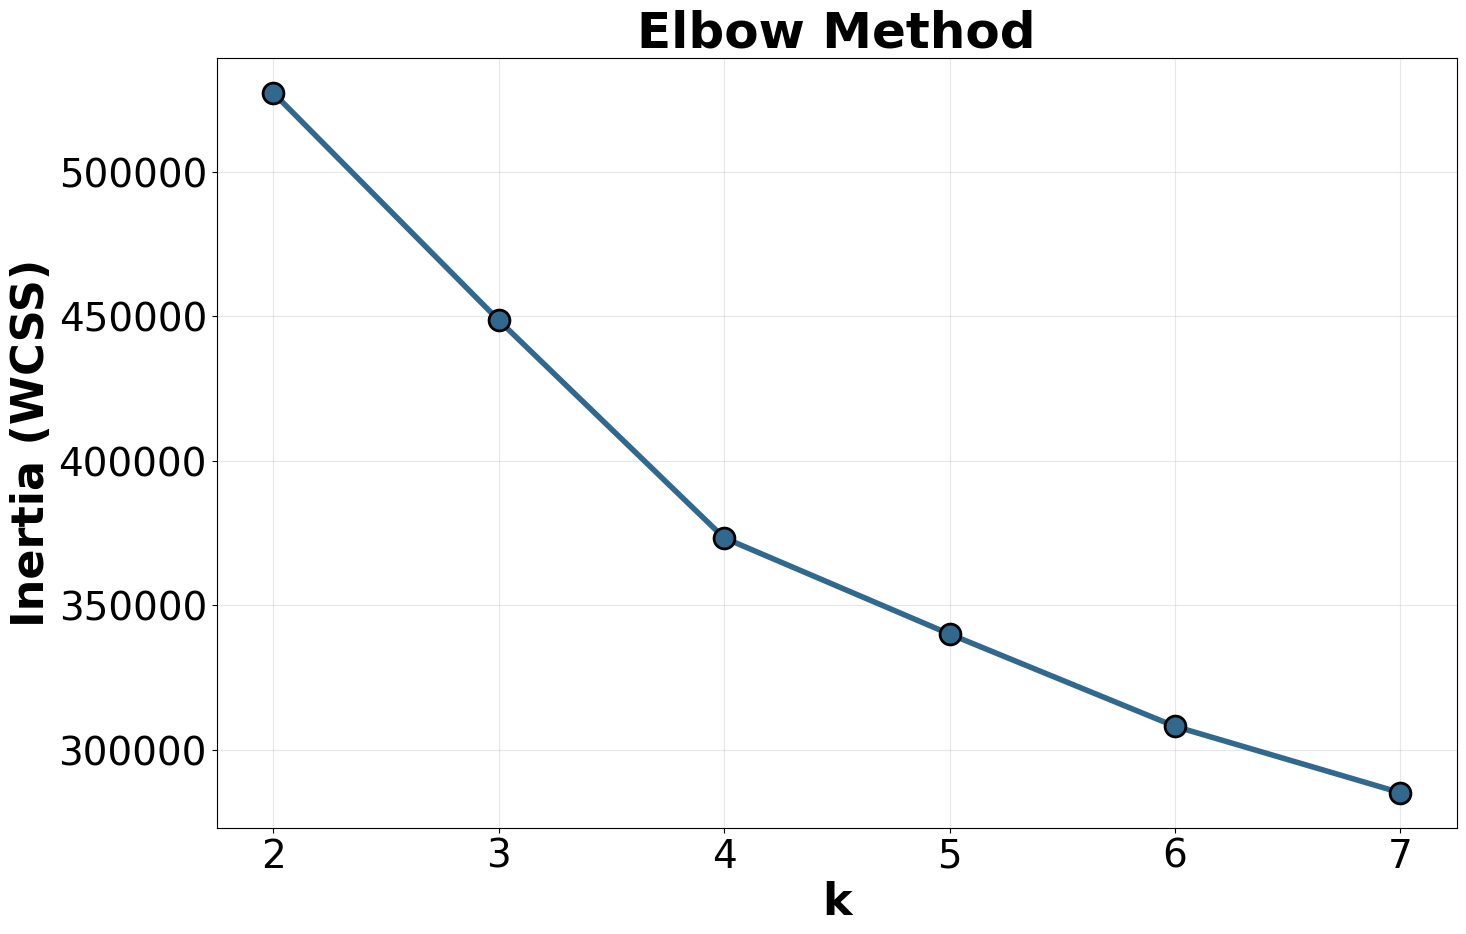

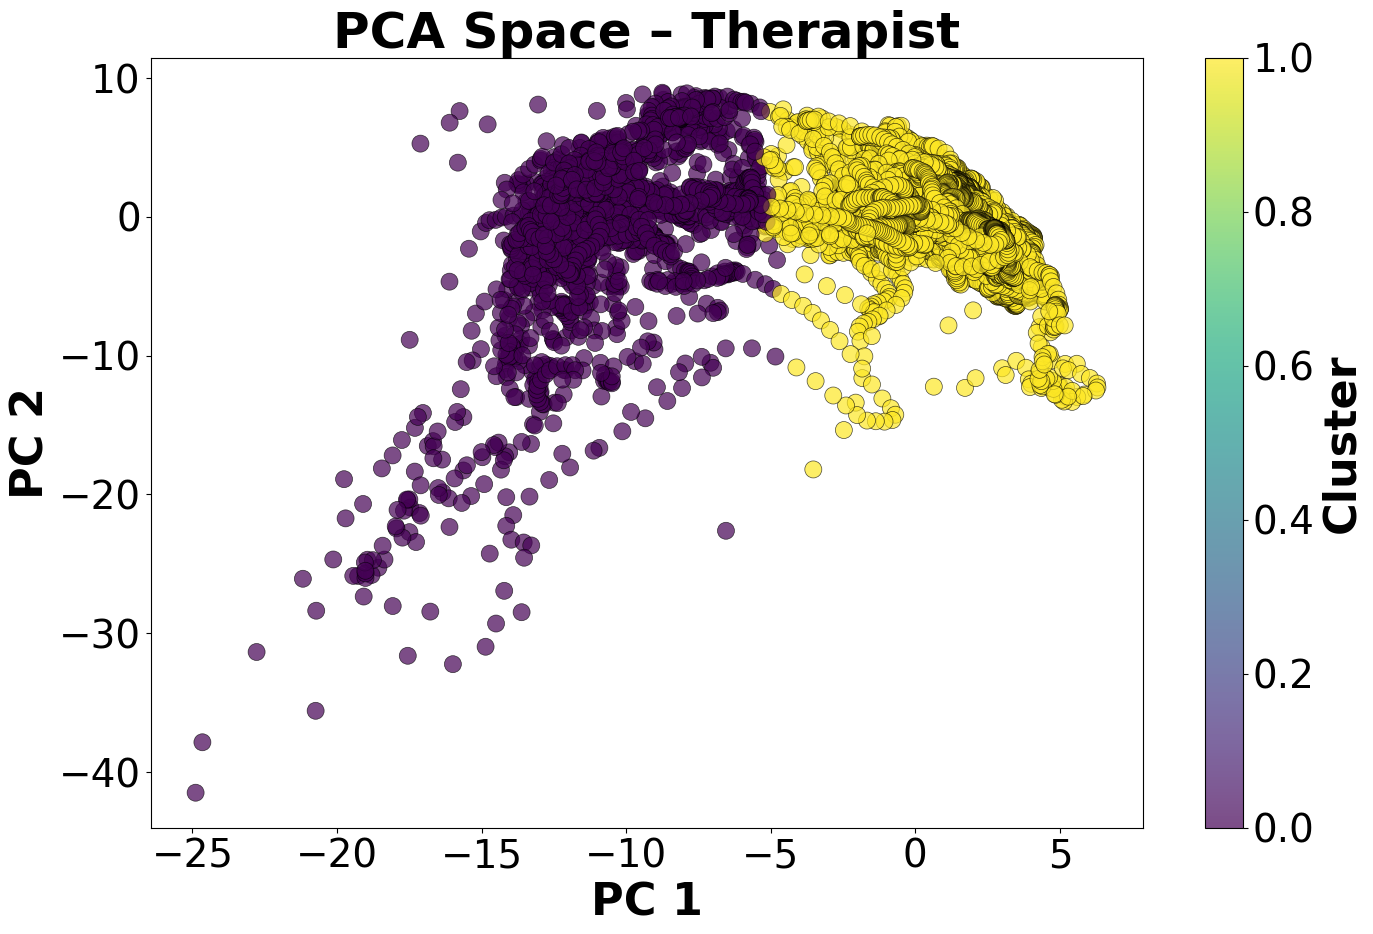

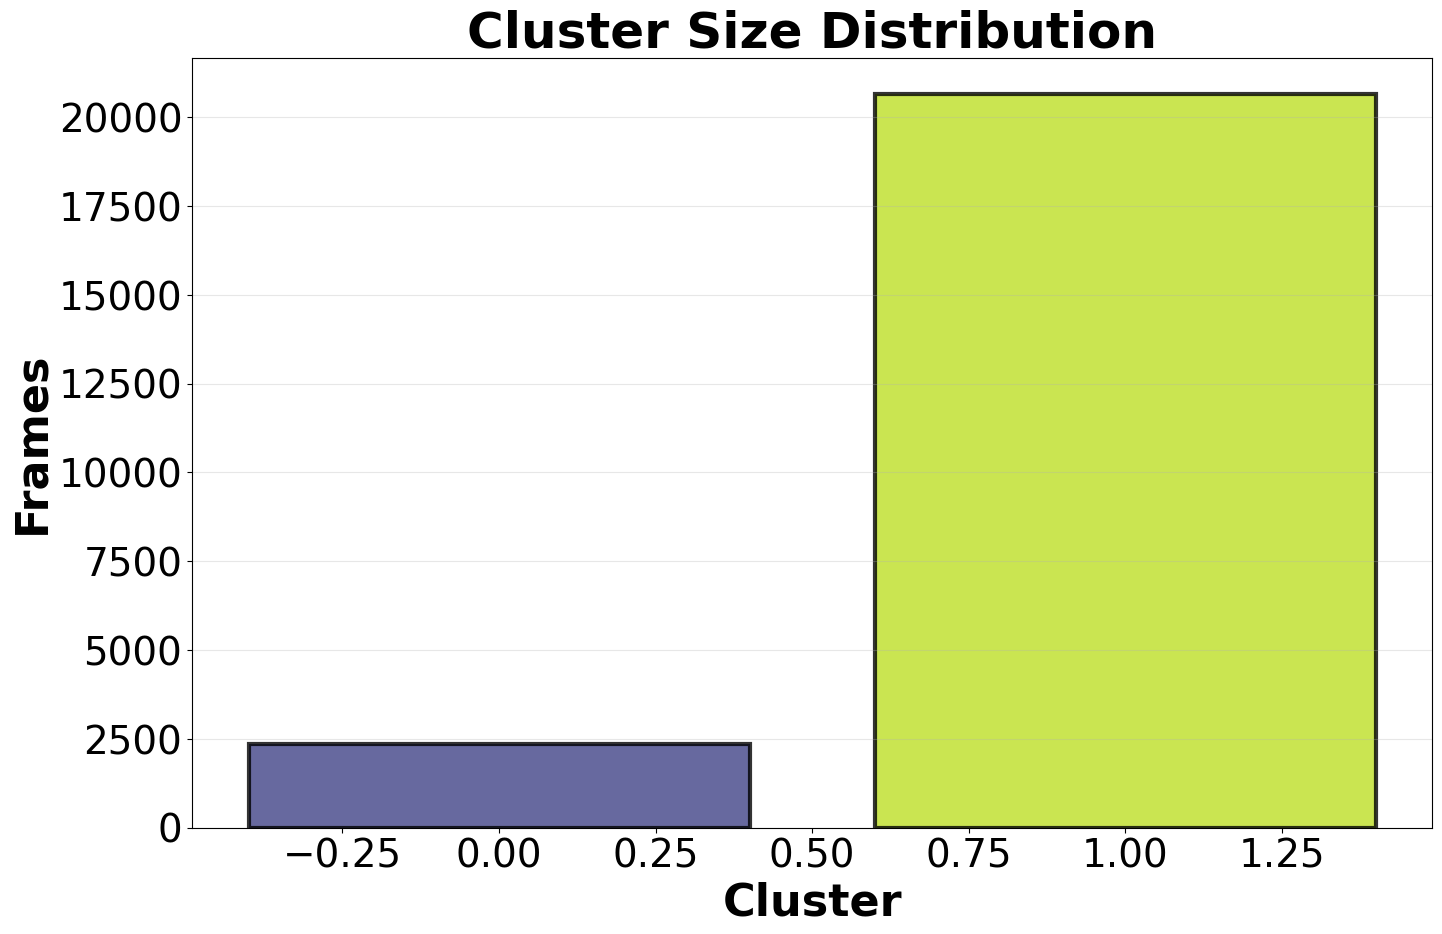

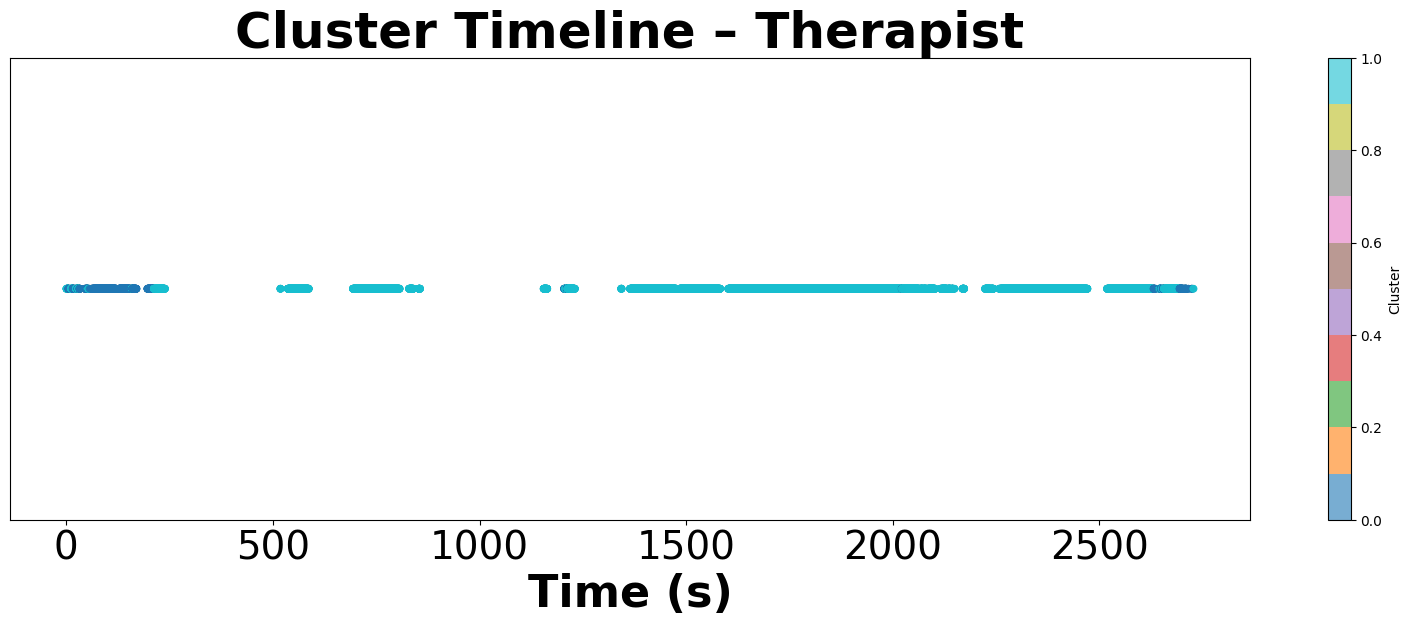


  ── Child ──
  [Child] feature matrix: 23507 frames × 38 features 
     → 13 keypoints (normalised coords) + 9 angles + 3 velocity features
  PCA: 11 components retained (95.9% variance explained)


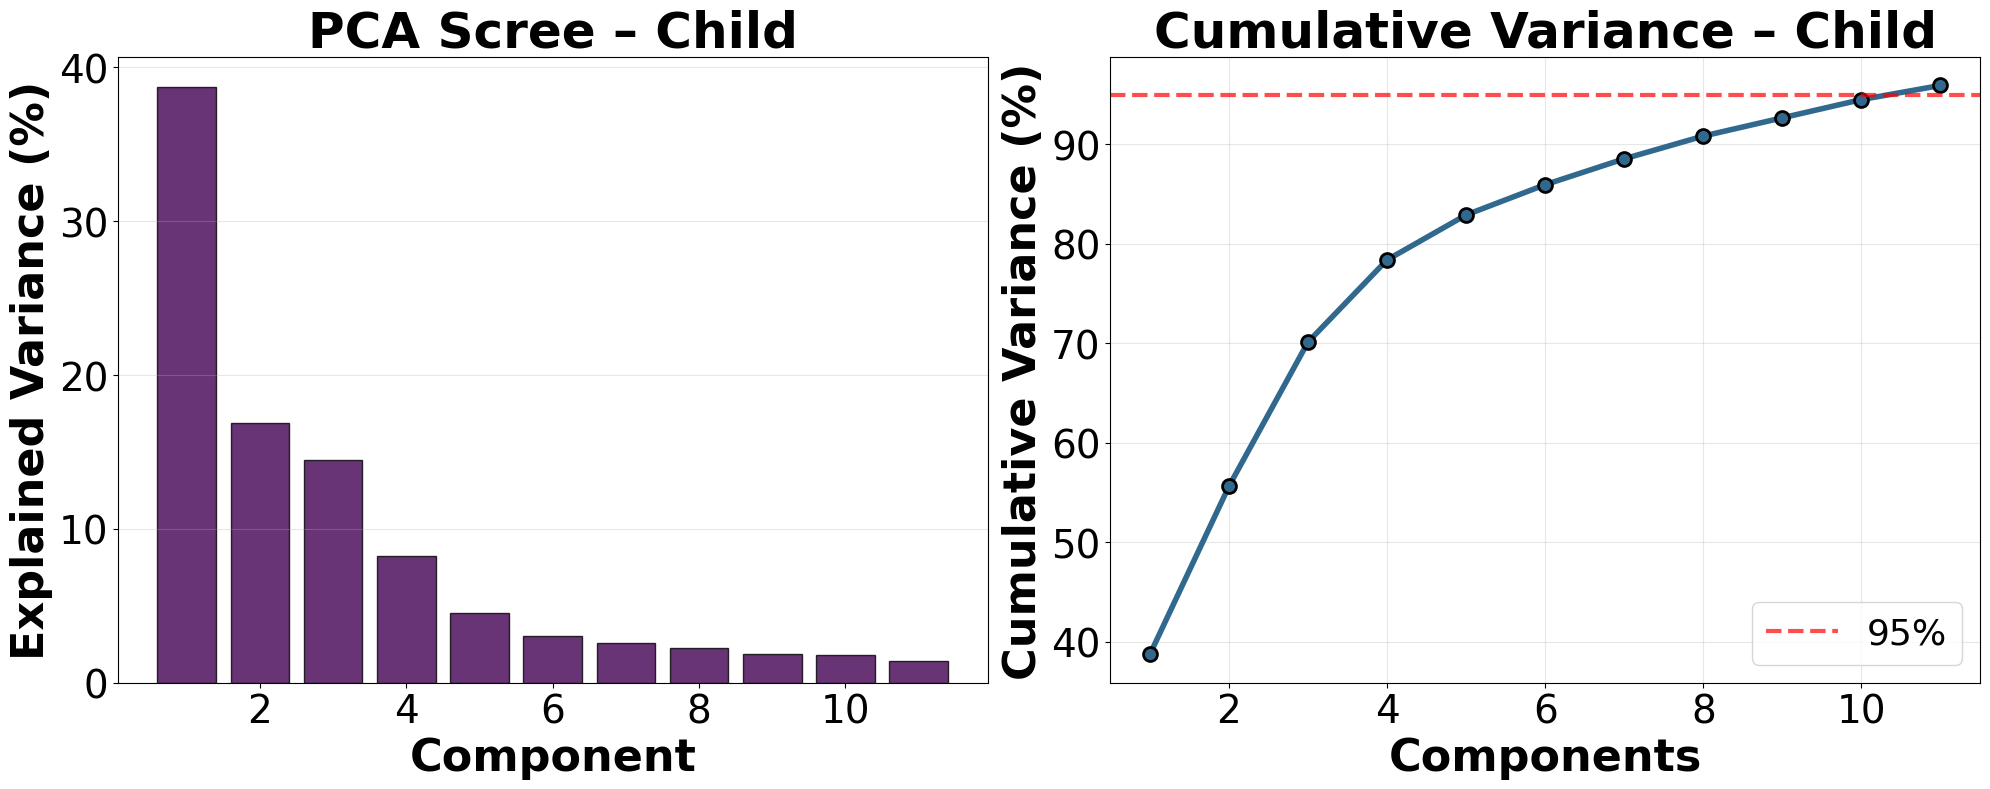

  Optimal k = 2  (silhouette: 0.876)
  Clustering: 2 clusters  (silhouette: 0.876)


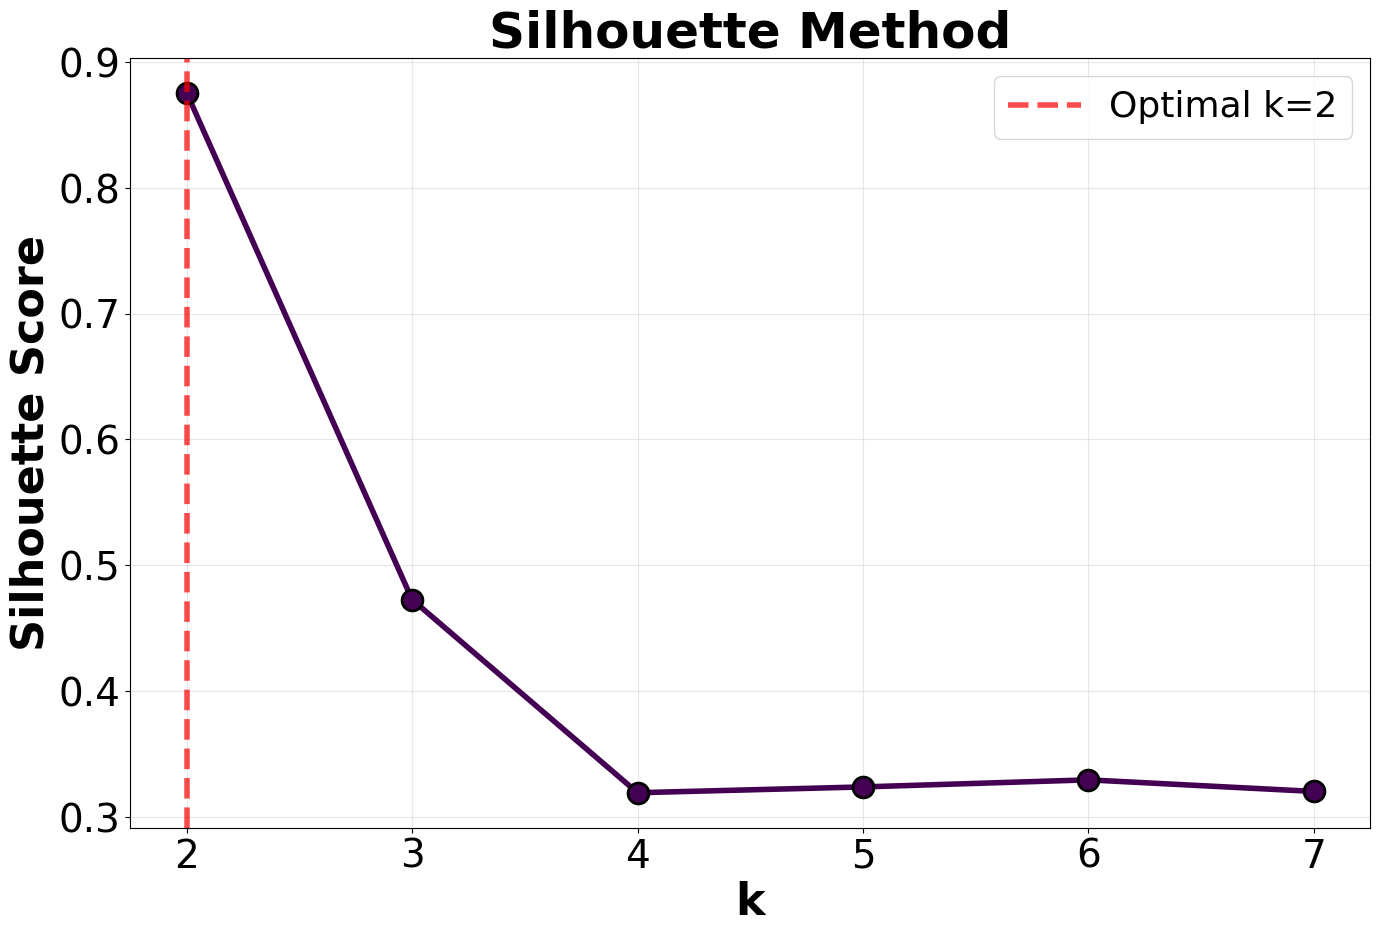

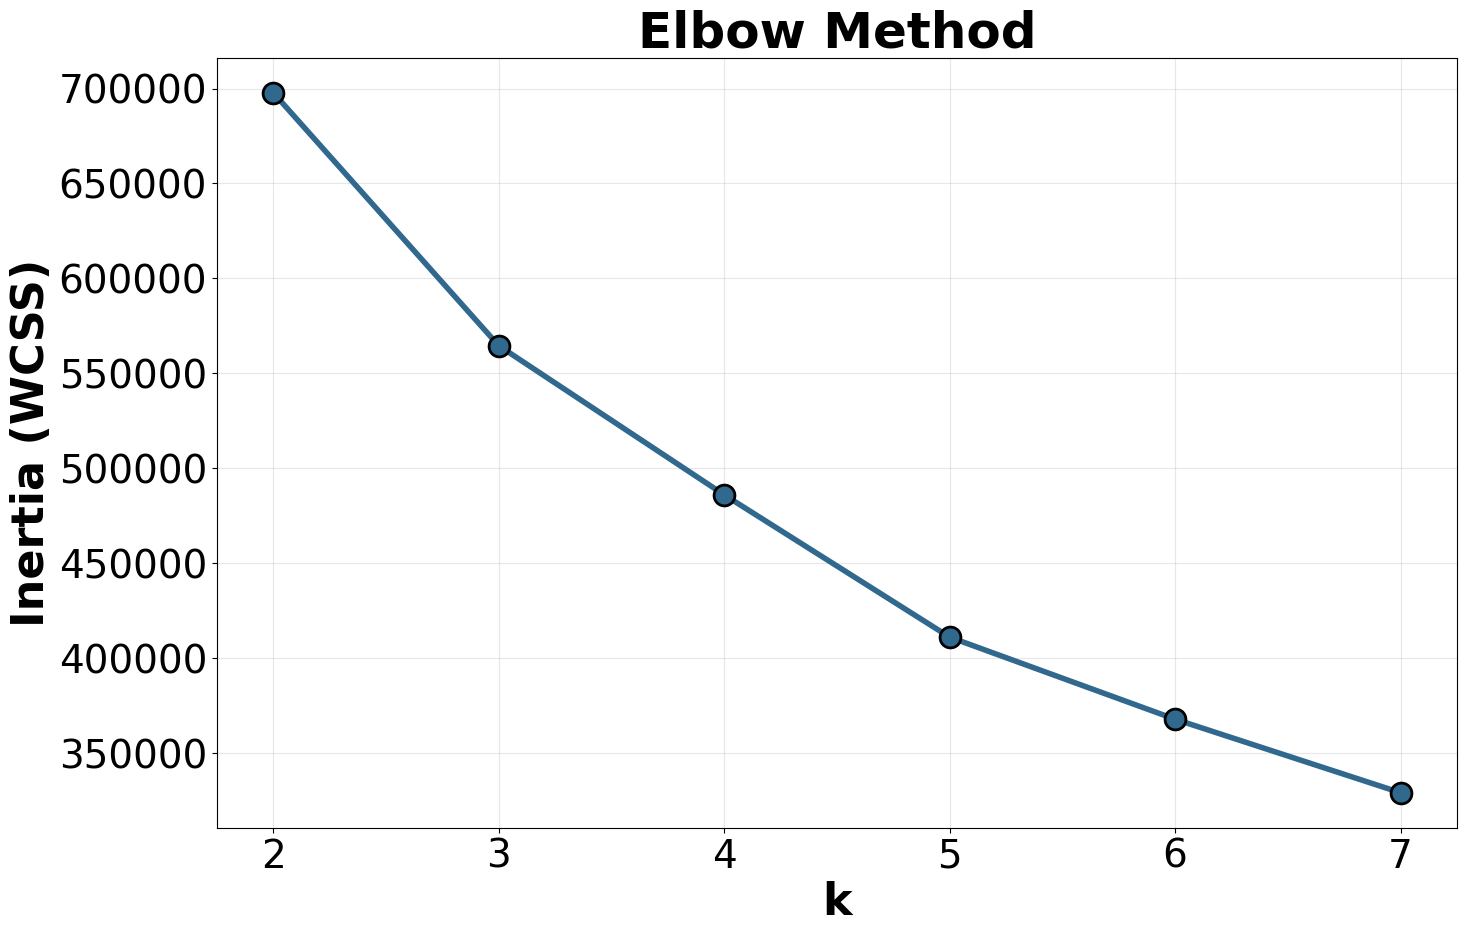

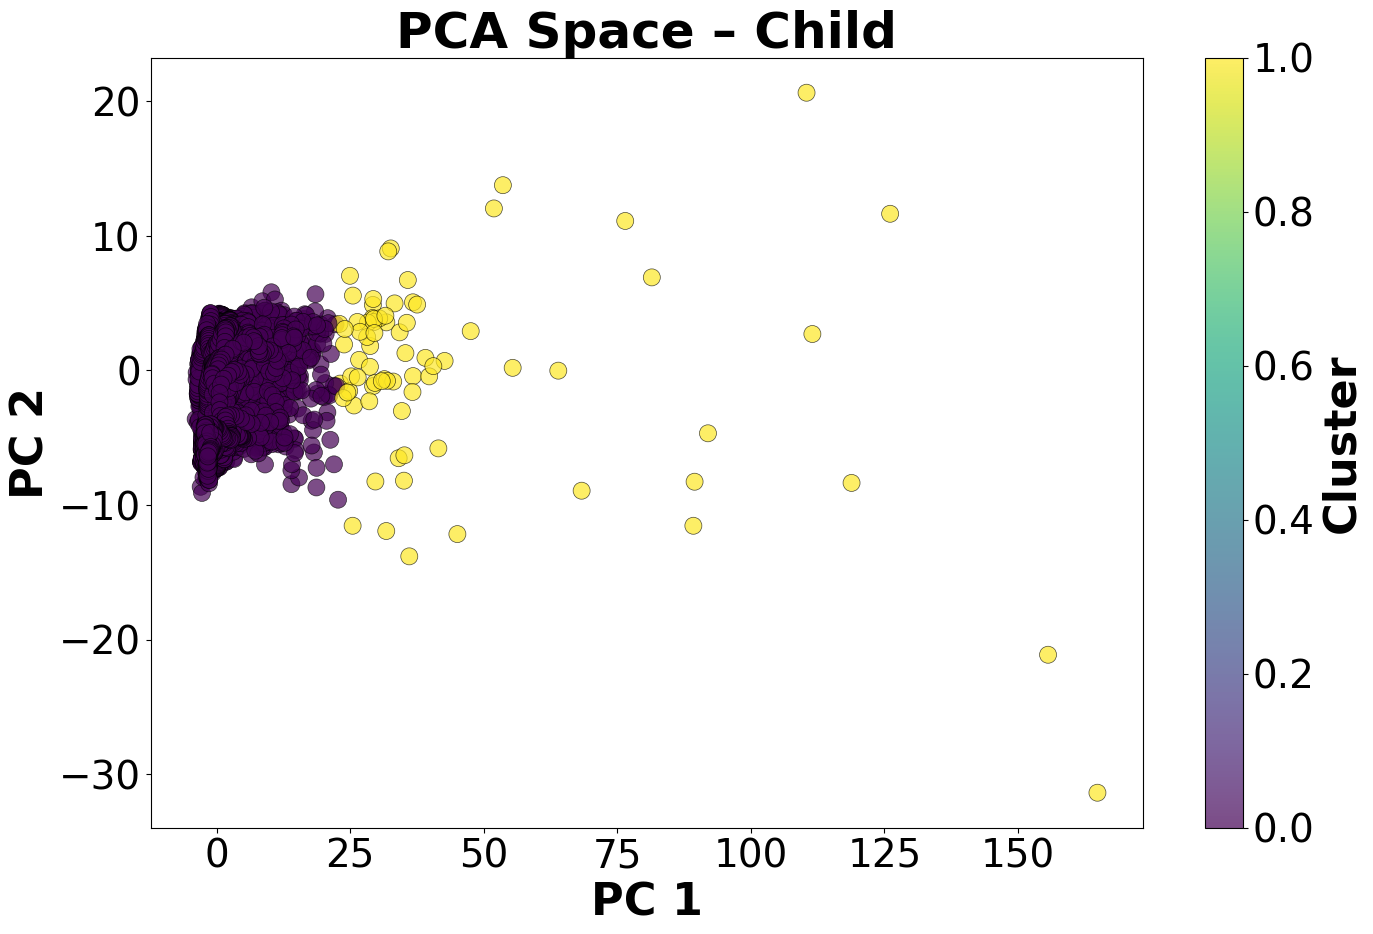

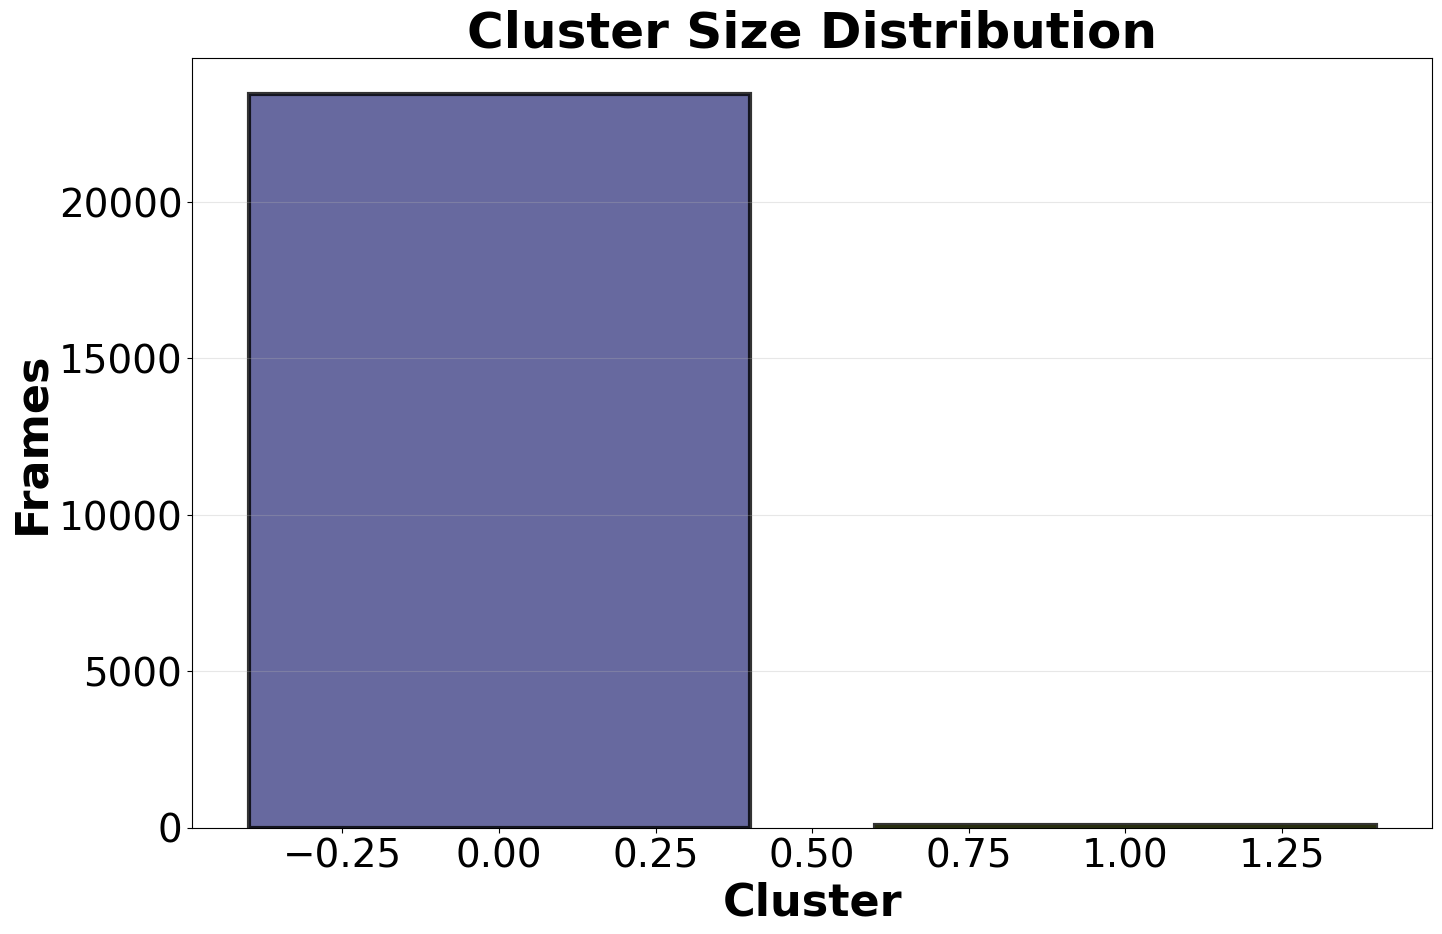

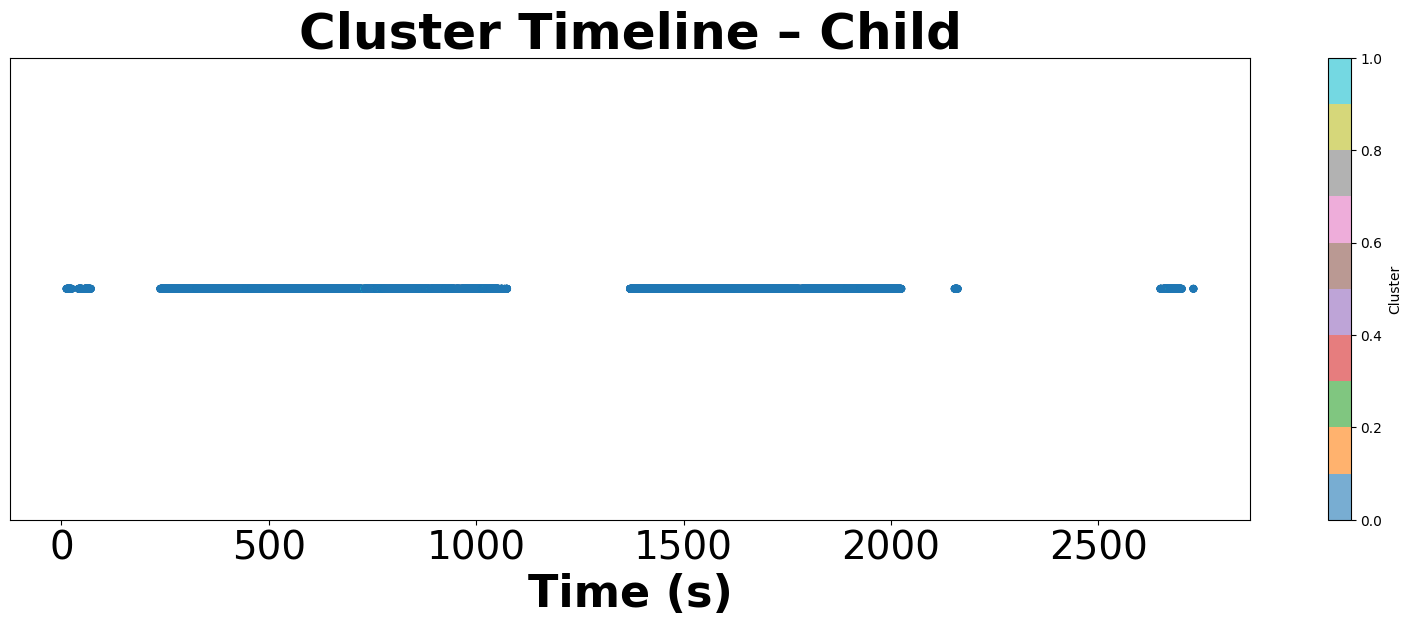


[5/5] Generating final results...
  Saved: Output/pose_clusters_with_clinical.csv

ANALYSIS COMPLETE – KEY FINDINGS

Dataset: 46,494 frames

Movement Profiles:
  • Therapist: 30.5% active  (mean speed 16.6 px/frame)
  • Child: 30.9% active  (mean speed 10.8 px/frame)

Proximity: 151 px avg distance  (97.9% close)

Responsiveness: 95.3% (1277/1340 approaches)
  Mean response latency: 0.59s

Movement Coupling: r = 0.284  at -1.6s lag

Pose Clusters (angle + coord features → PCA → K-Means):
  • Therapist: 2 posture clusters  | PCA: 11 components  | silhouette: 0.652
  • Child: 2 posture clusters  | PCA: 11 components  | silhouette: 0.876



In [10]:
if __name__ == "__main__":
    results = run_pose_clustering(
        data_path  = "",
        output_dir = "Output"
    )